# 03 Gradient Descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Gradient Descent
Gradient descent optimizes towards the local minimum of the cost function for the model parameters $\theta$. In general, one starts with a random set of values for $\theta$, and then iterates towards a (hopefully) global minimum by taking steps in the direction of steepest descent of the cost function. 

The first thing to note is that this is sensitive to data normalization, since the gradient will be proportional to the largest value feature, essentially minimizing this first, and then gradually minimizing the smaller features. This is why *normalization* is very important for gradient descent in general.

Further, an important parameter is the *learning rate*, which controls the step size. If this is too large it could bounce around the minimum, whereas if it is too small it will take too long to find the minimum. This is basically a damping problem, you want to find the critical damping rate.

Another thing to be careful of is local minima. If we do not have a way to kick ourselves out of a local minimum, then we can get stuck at a non-optimal solution (fortunately there are methods to help this, such as stochastic gradient descent). Some models do not have this problem as they are convex. An example of this is the MSE cost function with Linear Regression.

There are three main methods of gradient descent which we talk about in the following:
1. Batch gradient descent
2. Stochastic gradient descent
3. Mini-batch gradient descent

### 1.1. Batch gradient descent
This is full gradient descent, calculating the gradient of the MSE at the point $\theta$ on the *entire* data set, and then taking a step:
$$
\theta^{\mathrm{next}} = \theta - \eta \nabla_\theta \mathrm{MSE}(\theta)
$$
where $\eta$ is a constant learning rate.

*How do we stop the process?* We can set a maximum number of iterations, however we must note that this is strongly affected by how close to critical our learning rate is. Often we utilize a tolerance $\epsilon$ for the norm of the gradient.

**Note:** Batch gradient descent can be extremely slow on large datasets, since we are calculating the gradient on the entire dataset.


### 1.2 Stochastic Gradient Descent
Stochastic gradient descent takes a single random instance in the training set at every step and computes the gradient for that single point. This radically speeds up gradient calculation, at the cost of making the path towards the global minimum much less regular. It will also never settle down, as the inherent noise in our data will undermine the search for the minimum.

However, this randomness has the benefit that it is very good at jumping out of local minimum that aren't the true global minimum.

A solution to the fact that this method will never actually settle into the global minimum is to slowly reduce the learning rate via a *learning schedule*. You must take care in assigning this though, since reducing the jumps too rapidly could cause the algorithm to get stuck in a local minimum. Typically this is done in rounds of $m$ iterations, called *epochs*, meaning you go through the entire dataset a number of times, reducing the learning rate after each epoch. 

A useful note is that you should probably shuffle your dataset before applying stochastic gradient descent, in particular if your data is structured, since it assumes that your data is IID.



### 1.3 Mini-batch Gradient Descent

This method is like a mid-way between the previous two methods, as it computes the gradient on small random sets of instances called *mini-batches*. It is faster than batch gradient descent, since it isn't calculating the gradient on the full dataset, but it will wander more due to the stochasticity. It is also better at converging to the global minimum faster than stochastic gradient descent, but it could get stuck at local minima.


[]

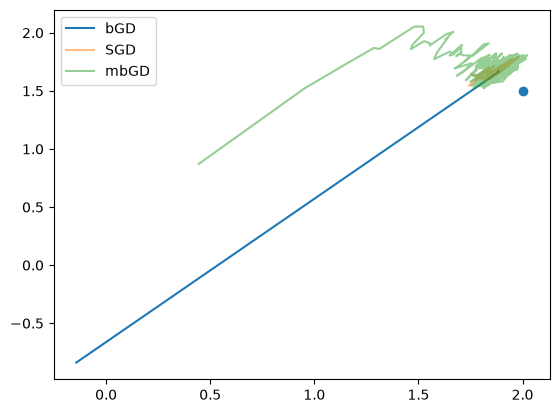

In [2]:
Xmax = 2       # Maximum X value
intercept = 2  # intercept of slope
slope = 1.5      # gradient of slope
randScale = 1  # scale of random data
num_data = 200

# Generate Data
X = Xmax * np.random.rand(num_data, 1)
y = intercept + slope * X + randScale * np.random.randn(num_data,1)
X_b = np.c_[np.ones((num_data, 1)), X] # adds x0 = 1 to each data point


# Batch gradient descent
eta = 0.1
n_iterations = 200
m = len(X)

theta = np.random.randn(2, 1)

theta_0_bGD = [theta[0]]
theta_1_bGD = [theta[1]]
for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients
    theta_0_bGD.append(theta[0])
    theta_1_bGD.append(theta[1])


# Stochastic gradient descent
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=1, tol=1e-3, penalty=None, eta0=eta)

theta_0_SGD = []
theta_1_SGD = []
sgd_reg.partial_fit(X, y.ravel())
for epoch in range(n_iterations):
    sgd_reg.partial_fit(X, y.ravel())
    theta_0_SGD.append(sgd_reg.intercept_[0])
    theta_1_SGD.append(sgd_reg.coef_[0])


# Mini-batch gradient descent
batch_size = 20
theta_0_mbGD = []
theta_1_mbGD = []
m = len(X_b)
y_b = y.reshape(-1, 1)
rng = np.random.default_rng(42)
theta = np.random.randn(2, 1)

for epoch in range(n_iterations):
    indices = rng.permutation(m)
    X_shuffled = X_b[indices]
    y_shuffled = y[indices]

    for start in range(0, m, batch_size):
        end = start + batch_size
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]
        m_batch = len(X_batch)
        gradients = 2/m_batch * X_batch.T.dot(X_batch.dot(theta) - y_batch)
        theta = theta - eta * gradients
        theta_0_mbGD.append(theta[0])
        theta_1_mbGD.append(theta[1])


plt.plot(theta_0_bGD, theta_1_bGD, label="bGD")

plt.plot(theta_0_SGD, theta_1_SGD, label="SGD", alpha=0.5)
#plt.scatter(theta_0_SGD[0], theta_1_SGD[0], color="green")#
#plt.scatter(theta_0_SGD[-1], theta_1_SGD[-1], color="red")

plt.plot(theta_0_mbGD, theta_1_mbGD, label="mbGD", alpha=0.5)
plt.scatter(intercept,slope)

plt.legend()
plt.plot()